# 315 사전 분석 — lv2 매크로의 5-feature space 위치 파악

**목적**: 매크로 다양화 축 결정을 위한 input. lv2 매크로가 5개 최종 feature space 에서 어디에 위치해 있는지 + lv2 알고리즘 특성 정리.

**제약**: lv2_macro vs lv2_human 만 (Balabit 제외). 새 feature 추가 X. 다양화 방향/매크로 종류 제안 X — 결과만.

**5 분석 대상 feature** (`models/classifier/input_features.json` 7개 중 사용자 지정 5개):
- `inter_click_interval_ms`
- `mouse_speed_change_mean`
- `mouse_max_speed_px_per_ms`
- `mouse_path_curvature_mean`
- `mouse_avg_speed_px_per_ms`

## 1. 데이터 로딩 + 카운트 검증

baseline (295 시점): `lv2_human=51, lv2_macro=101`. 추가 수집분이 있으면 명시.

In [1]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# trial_loader / plots 가 같은 EDA 폴더에 있음
EDA_DIR = Path.cwd()
if str(EDA_DIR) not in sys.path:
    sys.path.insert(0, str(EDA_DIR))

from trial_loader import list_trials_by_group, load_trial, sample_trials, event_rows_to_df
from plots import plot_trajectory

FEATURES = [
    "inter_click_interval_ms",
    "mouse_speed_change_mean",
    "mouse_max_speed_px_per_ms",
    "mouse_path_curvature_mean",
    "mouse_avg_speed_px_per_ms",
]

BASELINE_HUMAN_N = 51
BASELINE_MACRO_N = 101

In [2]:
def load_metrics_df(group: str) -> pd.DataFrame:
    metas = list_trials_by_group(group)
    rows = []
    for m in metas:
        trial = load_trial(m["trial_id"])
        metrics = trial.get("metrics", {})
        row = {"trial_id": m["trial_id"]}
        for f in FEATURES:
            row[f] = metrics.get(f)
        rows.append(row)
    return pd.DataFrame(rows)

df_human = load_metrics_df("lv2_human")
df_macro = load_metrics_df("lv2_macro")

print(f"lv2_human n = {len(df_human)}")
print(f"lv2_macro n = {len(df_macro)}")
print()

def report_count(name: str, n: int, baseline: int) -> None:
    delta = n - baseline
    if delta == 0:
        print(f"[ok] {name} baseline 일치 ({baseline})")
    else:
        sign = "+" if delta > 0 else ""
        print(f"[delta] {name} n={n} (Δ={sign}{delta} vs baseline {baseline}) — 추가 수집/필터 영향 가능")

report_count("lv2_human", len(df_human), BASELINE_HUMAN_N)
report_count("lv2_macro", len(df_macro), BASELINE_MACRO_N)

print()
print("NaN counts (5 feature):")
for f in FEATURES:
    nh = int(df_human[f].isna().sum())
    nm = int(df_macro[f].isna().sum())
    print(f"  {f}: human={nh}, macro={nm}")

lv2_human n = 51
lv2_macro n = 101

[ok] lv2_human baseline 일치 (51)
[ok] lv2_macro baseline 일치 (101)

NaN counts (5 feature):
  inter_click_interval_ms: human=0, macro=0
  mouse_speed_change_mean: human=0, macro=0
  mouse_max_speed_px_per_ms: human=0, macro=0
  mouse_path_curvature_mean: human=0, macro=0
  mouse_avg_speed_px_per_ms: human=0, macro=0


## 2. 5 feature 분포 시각화 (lv2_macro vs lv2_human overlay)

각 feature 별 histogram (density). mean 은 점선으로 표시.

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\1362122374.py:32: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\1362122374.py:32: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))


C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


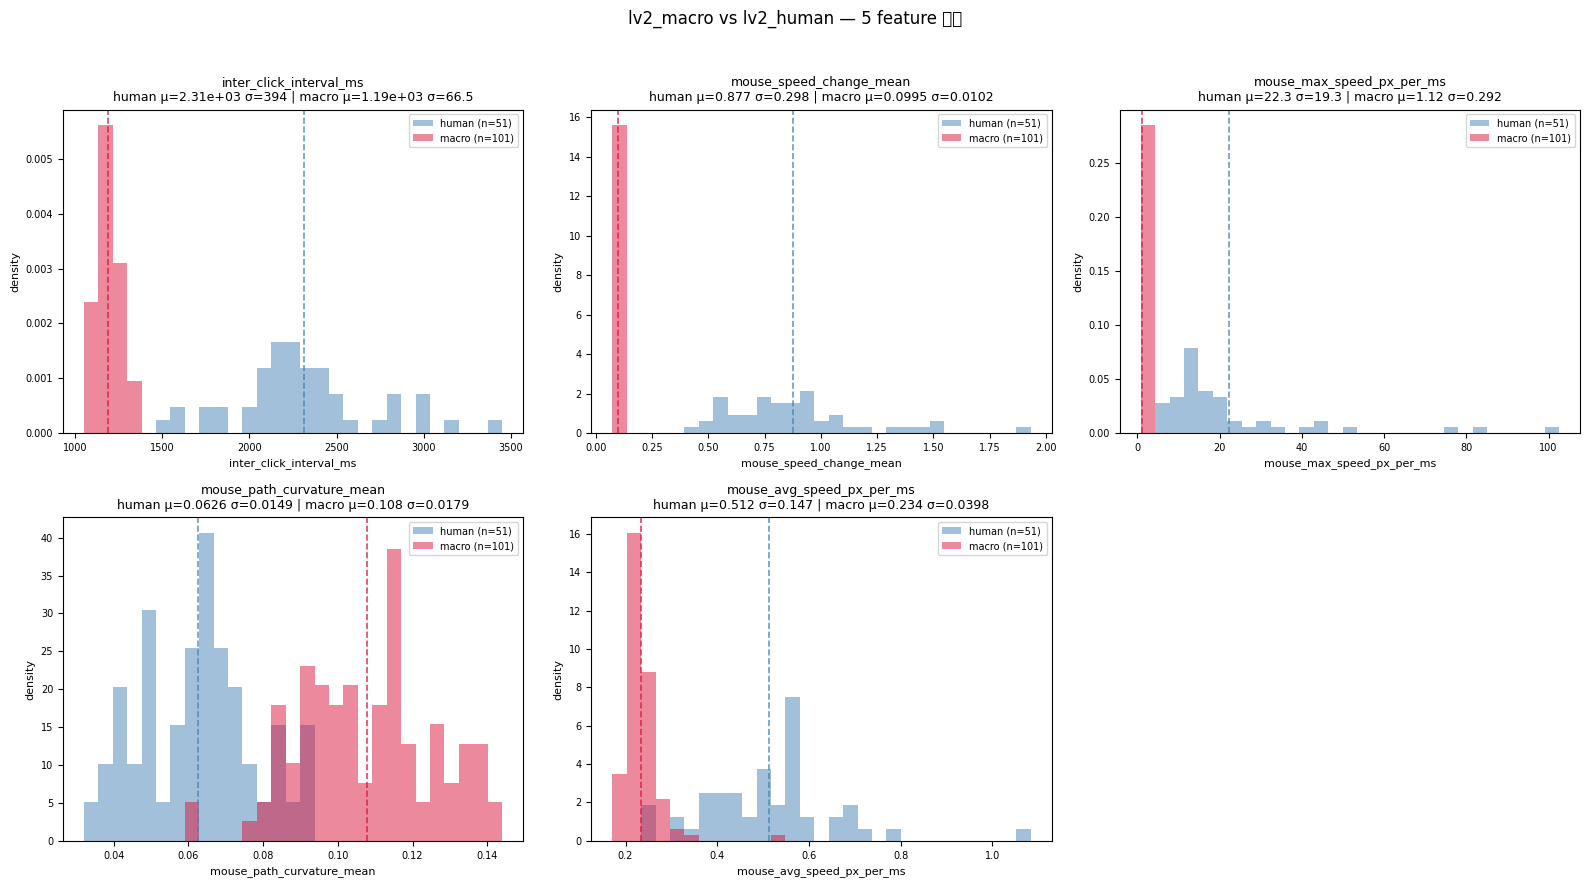

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes_flat = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes_flat[i]
    vh = df_human[feat].dropna().values
    vm = df_macro[feat].dropna().values
    combined = np.concatenate([vh, vm])
    bins = np.linspace(combined.min(), combined.max(), 30)

    ax.hist(vh, bins=bins, alpha=0.5, color="steelblue",
            label=f"human (n={len(vh)})", density=True)
    ax.hist(vm, bins=bins, alpha=0.5, color="crimson",
            label=f"macro (n={len(vm)})", density=True)

    ax.axvline(np.mean(vh), color="steelblue", linestyle="--", linewidth=1.2, alpha=0.8)
    ax.axvline(np.mean(vm), color="crimson", linestyle="--", linewidth=1.2, alpha=0.8)

    title = (
        f"{feat}\n"
        f"human μ={np.mean(vh):.3g} σ={np.std(vh):.3g} | "
        f"macro μ={np.mean(vm):.3g} σ={np.std(vm):.3g}"
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel(feat, fontsize=8)
    ax.set_ylabel("density", fontsize=8)
    ax.tick_params(labelsize=7)
    ax.legend(fontsize=7)

axes_flat[5].axis("off")
fig.suptitle("lv2_macro vs lv2_human — 5 feature 분포", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

## 3. 정량 지표 표

- `std_ratio (h/m)`: human std / macro std (클수록 macro 가 좁음)
- `overlap_pct`: macro range ∩ human range / human range × 100 (lv2 가 커버하는 human 영역 비율)
- `macro_median_at_human_pct`: human 분포에서 macro median 이 차지하는 percentile

In [4]:
def feature_stats(vh: np.ndarray, vm: np.ndarray) -> dict:
    h_min, h_max = float(vh.min()), float(vh.max())
    m_min, m_max = float(vm.min()), float(vm.max())
    overlap_lo = max(h_min, m_min)
    overlap_hi = min(h_max, m_max)
    overlap_size = max(0.0, overlap_hi - overlap_lo)
    human_range = h_max - h_min
    overlap_pct = (overlap_size / human_range * 100) if human_range > 0 else 0.0

    m_med = float(np.median(vm))
    h_pct_at_m_med = float((vh < m_med).sum()) / len(vh) * 100

    h_std = float(np.std(vh))
    m_std = float(np.std(vm))
    return {
        "macro_mean": float(np.mean(vm)),
        "macro_std": m_std,
        "macro_min": m_min,
        "macro_max": m_max,
        "human_mean": float(np.mean(vh)),
        "human_std": h_std,
        "human_min": h_min,
        "human_max": h_max,
        "std_ratio_h_m": (h_std / m_std) if m_std > 0 else float("inf"),
        "overlap_pct": overlap_pct,
        "macro_med_at_human_pct": h_pct_at_m_med,
    }

stats_rows = []
for feat in FEATURES:
    vh = df_human[feat].dropna().values
    vm = df_macro[feat].dropna().values
    s = feature_stats(vh, vm)
    s["feature"] = feat
    stats_rows.append(s)

stats_df = pd.DataFrame(stats_rows).set_index("feature")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print(stats_df.to_string(float_format=lambda x: f"{x:.4g}"))

                           macro_mean  macro_std  macro_min  macro_max  human_mean  human_std  human_min  human_max  std_ratio_h_m  overlap_pct  macro_med_at_human_pct
feature                                                                                                                                                                
inter_click_interval_ms          1191      66.51       1050       1363        2313      393.9       1535       3449          5.922            0                       0
mouse_speed_change_mean       0.09945    0.01016     0.0741     0.1255      0.8773     0.2982     0.4576      1.932          29.36            0                       0
mouse_max_speed_px_per_ms       1.121     0.2921     0.7987      2.899       22.26      19.29      5.656      102.6          66.05            0                       0
mouse_path_curvature_mean      0.1078     0.0179    0.06238      0.144     0.06261    0.01492      0.032    0.09213         0.8334        49.47                 

In [5]:
print("Human 분포에서 macro range 가 커버하지 못하는 영역 (percent):")
for feat in FEATURES:
    vh = df_human[feat].dropna().values
    vm = df_macro[feat].dropna().values
    m_min, m_max = float(vm.min()), float(vm.max())
    pct_below = float((vh < m_min).sum()) / len(vh) * 100
    pct_above = float((vh > m_max).sum()) / len(vh) * 100
    pct_inside = 100 - pct_below - pct_above
    print(f"  {feat}:")
    print(f"    human {pct_below:5.1f}% < macro_min({m_min:.4g})")
    print(f"    human {pct_inside:5.1f}% inside macro range")
    print(f"    human {pct_above:5.1f}% > macro_max({m_max:.4g})")

Human 분포에서 macro range 가 커버하지 못하는 영역 (percent):
  inter_click_interval_ms:
    human   0.0% < macro_min(1050)
    human   0.0% inside macro range
    human 100.0% > macro_max(1363)
  mouse_speed_change_mean:
    human   0.0% < macro_min(0.0741)
    human   0.0% inside macro range
    human 100.0% > macro_max(0.1255)
  mouse_max_speed_px_per_ms:
    human   0.0% < macro_min(0.7987)
    human   0.0% inside macro range
    human 100.0% > macro_max(2.899)
  mouse_path_curvature_mean:
    human  47.1% < macro_min(0.06238)
    human  52.9% inside macro range
    human   0.0% > macro_max(0.144)
  mouse_avg_speed_px_per_ms:
    human   0.0% < macro_min(0.1712)
    human  51.0% inside macro range
    human  49.0% > macro_max(0.5177)


## 4. lv2 위치 분류

각 feature 별로 lv2 macro 분포가 human 분포의 어느 영역에 위치하는지 자동 판정.
- macro range 가 human range 의 25% 미만 → "좁은 구간"
- macro median 의 human percentile 위치로 "하위/중앙/상위" 판단
- macro range 가 human range 와 미겹침 → "외부"

In [6]:
def classify_position(vh: np.ndarray, vm: np.ndarray) -> str:
    h_min, h_max = float(vh.min()), float(vh.max())
    m_min, m_max = float(vm.min()), float(vm.max())
    h_range = h_max - h_min
    m_range = m_max - m_min

    if m_max < h_min or m_min > h_max:
        return f"human 분포 외부 (미겹침) — macro [{m_min:.3g}, {m_max:.3g}] vs human [{h_min:.3g}, {h_max:.3g}]"

    width_ratio = (m_range / h_range) if h_range > 0 else 0
    h_q25 = float(np.percentile(vh, 25))
    h_q75 = float(np.percentile(vh, 75))
    m_med = float(np.median(vm))

    if width_ratio < 0.25:
        if m_med < h_q25:
            return f"좁은 구간 + 하위 25% 이하 (width {width_ratio:.0%})"
        elif m_med > h_q75:
            return f"좁은 구간 + 상위 25% 이상 (width {width_ratio:.0%})"
        else:
            return f"좁은 중앙 구간 (width {width_ratio:.0%})"
    else:
        if m_med < h_q25:
            return f"한쪽 극단 (하위, width {width_ratio:.0%})"
        elif m_med > h_q75:
            return f"한쪽 극단 (상위, width {width_ratio:.0%})"
        else:
            return f"human 분포와 일부 겹침 — 중앙 (width {width_ratio:.0%})"

print("lv2 macro 위치 분류:")
for feat in FEATURES:
    vh = df_human[feat].dropna().values
    vm = df_macro[feat].dropna().values
    cls = classify_position(vh, vm)
    print(f"  {feat}: {cls}")

lv2 macro 위치 분류:
  inter_click_interval_ms: human 분포 외부 (미겹침) — macro [1.05e+03, 1.36e+03] vs human [1.54e+03, 3.45e+03]
  mouse_speed_change_mean: human 분포 외부 (미겹침) — macro [0.0741, 0.126] vs human [0.458, 1.93]
  mouse_max_speed_px_per_ms: human 분포 외부 (미겹침) — macro [0.799, 2.9] vs human [5.66, 103]
  mouse_path_curvature_mean: 한쪽 극단 (상위, width 136%)
  mouse_avg_speed_px_per_ms: 한쪽 극단 (하위, width 41%)


## 5. Raw 궤적 시각화 — macro 3 + human 3 (seed=42)

위 row = lv2_macro 3세션 (베지어 매끄러움 / 등간격 step 시각 확인). 아래 row = lv2_human 3세션.

C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\4251427885.py:15: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\4251427885.py:15: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\4251427885.py:15: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\4251427885.py:15: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))
C:\Users\SSAFY\AppData\Local\Temp\ipykernel_40244\4251427885.py:15: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(rect=(0, 0, 1, 0.96))


C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44452 (\N{HANGUL SYLLABLE GWE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50500 (\N{HANGUL SYLLABLE A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

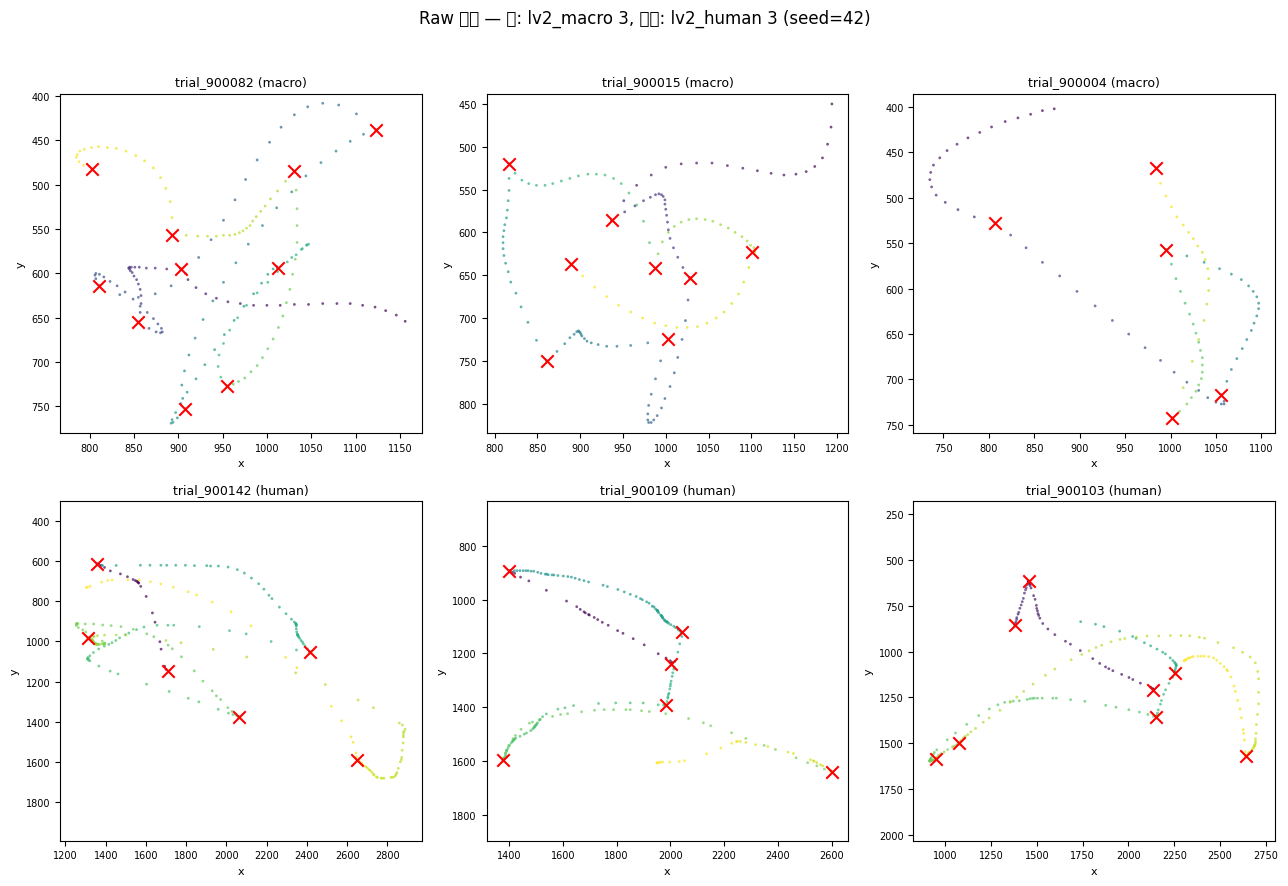

In [7]:
macro_metas = sample_trials("lv2_macro", n=3, seed=42)
human_metas = sample_trials("lv2_human", n=3, seed=42)

fig, axes = plt.subplots(2, 3, figsize=(13, 9))

for i, meta in enumerate(macro_metas):
    trial = load_trial(meta["trial_id"])
    plot_trajectory(trial, ax=axes[0, i])

for i, meta in enumerate(human_metas):
    trial = load_trial(meta["trial_id"])
    plot_trajectory(trial, ax=axes[1, i])

fig.suptitle("Raw 궤적 — 위: lv2_macro 3, 아래: lv2_human 3 (seed=42)", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()

C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\SSAFY\miniforge3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49496 (\N{HANGUL SYLLABLE SYEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(b

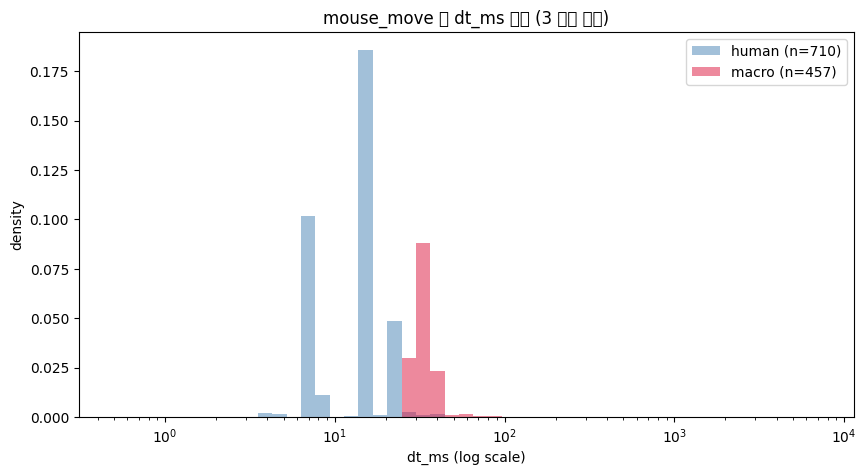

macro dt_ms: median=33.20, std=110.89, min=28.05, max=814.14, n=457
human dt_ms: median=15.03, std=440.28, min=0.36, max=7064.93, n=710


In [8]:
def collect_dt(metas: list[dict]) -> np.ndarray:
    out = []
    for m in metas:
        trial = load_trial(m["trial_id"])
        df = event_rows_to_df(trial)
        valid = df[df["is_move"]].dropna(subset=["dt_ms"])
        out.extend(valid["dt_ms"].astype(float).tolist())
    arr = np.array([v for v in out if v > 0])
    return arr

dt_macro = collect_dt(macro_metas)
dt_human = collect_dt(human_metas)

fig, ax = plt.subplots(figsize=(10, 5))
lo = min(dt_macro.min(), dt_human.min())
hi = max(dt_macro.max(), dt_human.max())
bins = np.logspace(np.log10(max(lo, 0.5)), np.log10(hi + 1), 50)
ax.hist(dt_human, bins=bins, alpha=0.5, color="steelblue",
        label=f"human (n={len(dt_human)})", density=True)
ax.hist(dt_macro, bins=bins, alpha=0.5, color="crimson",
        label=f"macro (n={len(dt_macro)})", density=True)
ax.set_xscale("log")
ax.set_xlabel("dt_ms (log scale)")
ax.set_ylabel("density")
ax.set_title("mouse_move 간 dt_ms 분포 (3 세션 합산)")
ax.legend()
plt.show()

print(f"macro dt_ms: median={np.median(dt_macro):.2f}, std={np.std(dt_macro):.2f}, "
      f"min={dt_macro.min():.2f}, max={dt_macro.max():.2f}, n={len(dt_macro)}")
print(f"human dt_ms: median={np.median(dt_human):.2f}, std={np.std(dt_human):.2f}, "
      f"min={dt_human.min():.2f}, max={dt_human.max():.2f}, n={len(dt_human)}")

## 6. lv2 매크로 알고리즘 특성 정리

출처: `services/ai/macro/mouse_automation/collector/lv2_collector.py`, `services/ai/macro/mouse_automation/core/mouse_utils.py`

### 궤적 생성
- **De Casteljau Bezier 곡선** (`mouse_utils.py:bezier_curve`)
  - 시작점 + 끝점 + **제어점 2개** (t=1/3, 2/3 위치, Gaussian offset σ=80px)
  - **20 path points** (`BEZIER_POINTS=20`) 균등 t 분할
  - 결과: smooth, **모노톤 곡률**의 단순 곡선. micro-tremor / overshoot / 자기보정 동작 없음
- **Path point 노이즈 X** — bezier 결과에 추가 노이즈 가하지 않음 (target 좌표에만 σ=4px Gaussian 노이즈)

### Step timing (mouse_move 간 간격)
- **균등 분할**: `step_time = total_duration / 20` — 한 세그먼트 내 모든 step 의 dt_ms 가 동일
- **total_duration = Fitts 법칙** (`mouse_utils.py:human_like_duration`):
  - `0.05 + 0.5 * log2(1 + distance_px) / 10`
  - × `random.uniform(0.8, 1.2)` (±20% jitter)
- 결과: dt_ms 분포가 거리별 구간으로 클러스터링됨 (사람은 연속적/멱법칙)

### 클릭 간 delay (`random_delay`)
- `random.lognormvariate(log(mean), σ=0.4)` clipped to **[0.1, 0.8]s**
- mean = (0.1+0.8)/2 = 0.45s
- 결과: 좁은 분포 (clip 영향). 클릭 직전 ~20 mouse_move 더하면 inter_click 1.0~1.4s 좁은 구간

### 클릭 수 / 좌표
- 세션당 **5~15 random clicks** (`run_session(clicks_min=5, clicks_max=15)`)
- 좌표: SAFE_X [800,1200] × SAFE_Y [400,800] uniform random, 인접 ≥50px
- target 에 σ=4px Gaussian 노이즈 (final click 좌표)

### 인간성 모방 — 포함 vs 누락
| 요소 | lv2 구현 | 비고 |
|---|---|---|
| 곡선 궤적 | ✅ (Bezier 2 control) | 모노톤 곡률 단순 곡선 |
| 거리 기반 duration | ✅ (Fitts 근사) | log2 + ±20% jitter |
| 좌표 노이즈 | ✅ (target 만 σ=4px) | path 점에는 X |
| 클릭 간 delay | ✅ (lognormal 클립) | 0.1~0.8s 좁은 분포 |
| **micro-tremor** | ❌ | path 점 진동 없음 |
| **overshoot / 보정** | ❌ | 단조 접근 only |
| **자연 멈춤 (pause)** | ❌ | 등간격 step |
| **속도 비대칭 프로파일** | ❌ | 곡선 위 균등 step |
| **가속/감속 jerk 변동** | ❌ | step time 일정 |
| **클릭 후 hover/drift** | ❌ | 즉시 다음 target |
| **휴면 / 긴 idle** | ❌ | max delay 0.8s 클립 |

## 7. 최종 결론 (사용자 형식)

**카운트 검증**: `lv2_human n=51`, `lv2_macro n=101` — 295 baseline 일치. 5 feature 모두 NaN=0.

### 5 feature 별 lv2 위치 / human 미커버 영역

1. **`inter_click_interval_ms`**
   - lv2 는 **[1050, 1363] ms 좁은 구간** 에 몰려 있음 (macro σ=66.5 ms, human σ=393.9 ms — 5.9배 좁음).
   - human 분포 중 **[1535, 3449] ms 전 영역 (human 100%)** 은 lv2 가 커버 못 함.
   - 위치 분류: **human 분포 외부 (미겹침)**. lv2 가 더 빠른 클릭 측에 고정됨.

2. **`mouse_speed_change_mean`**
   - lv2 는 **[0.074, 0.126] 좁은 구간** 에 몰려 있음 (std_ratio 29.4 — 5 feature 중 두 번째로 좁음).
   - human 분포 중 **[0.458, 1.93] 전 영역 (human 100%)** 은 lv2 가 커버 못 함.
   - 위치 분류: **human 분포 외부 (미겹침)**. segment 간 속도 변화 자체가 human 의 최저보다도 훨씬 작음.

3. **`mouse_max_speed_px_per_ms`**
   - lv2 는 **[0.80, 2.90] px/ms 좁은 구간** 에 몰려 있음 (std_ratio 66.0 — **5 feature 중 가장 좁음**).
   - human 분포 중 **[5.66, 102.6] px/ms 전 영역 (human 100%)** 은 lv2 가 커버 못 함.
   - 위치 분류: **human 분포 외부 (미겹침)**. lv2 max < human min — `total_duration/20` 균등 step 분할이 자연 발생하는 단발적 빠른 동작을 못 만듦.

4. **`mouse_path_curvature_mean`**
   - lv2 는 **[0.062, 0.144] rad/px** 의 **human 보다 큰 영역**에 위치 (macro median 이 human 분포의 100% percentile = human 모든 값보다 큼).
   - **macro std (0.0179) > human std (0.0149)** — 5 feature 중 유일하게 macro 가 human 보다 변동이 큼 (Bezier 제어점 random offset σ=80px 영향).
   - human 분포 중 **[0.032, 0.062] rad/px 영역 (human 의 47%)** 은 lv2 가 커버 못 함 — Bezier 2 control point 가 곡률을 인위적으로 강제해 human 의 직선~약곡선 영역 미커버.
   - 위치 분류: **한쪽 극단 (상위, width 136%)**.

5. **`mouse_avg_speed_px_per_ms`**
   - lv2 는 **[0.171, 0.518] px/ms** — human 분포 **하위~중앙 영역** 에 위치 (5 feature 중 유일하게 부분 겹침, overlap 33%).
   - human 분포 중 **[0.518, 1.083] px/ms 영역 (human 의 49%)** 은 lv2 가 커버 못 함 — Fitts log2 duration 이 평균 속도를 일정 범위에 가둠. human 의 빠른 절반은 미커버.
   - 위치 분류: **한쪽 극단 (하위, width 41%)**.

### lv2 알고리즘 특성 한 줄 요약

lv2 = (Bezier 2-control + Fitts log2-duration + 20 등간격 step + target σ=4px + lognormal-clipped[0.1, 0.8]s delay). **micro-tremor / overshoot / 자연 멈춤 (pause) / 가속도 변동 / 속도 비대칭 / 클릭 후 hover-drift / 긴 idle 모두 부재** — 결과적으로 5 feature 중 **3개 (간격, 속도 변화, max 속도) 에서 human 과 미겹침**, 1개 (곡률) 에서 human 보다 큰 인위적 영역, 1개 (평균 속도) 에서 human 하위 절반에만 위치.

### 보조 관찰 (셀 5, 12 raw 궤적)

- **궤적 plot**: macro 3세션 모두 매끄러운 단일 곡선 (방향 전환 후 보정 동작 없음). human 3세션은 jitter 와 보정 동작 가시.
- **dt_ms 분포**: macro 는 거리별 클러스터로 좁게 뭉침 (등간격 step 의 시각 증거). human 은 log scale 에서 연속적 / 멱법칙 모양.

### 한계 / 메모

- 본 분석은 lv2 vs lv2_human (1인) 만 — human 분포 폭이 다중 사용자 보다 좁을 수 있음 (295 도미노 결론과 동일 가정).
- matplotlib 한글 글리프 missing 경고 발생 (DejaVu Sans 미지원) — plot 내 한글 단어가 일부 깨질 수 있음. 결과 해석엔 영향 없음.
- 다양화 방향 / 추가 매크로 종류 제안은 본 분석 범위 외 (사용자 명시).